# step 1 — EDA and Data Preprocessing

### Contents
- **Part A** — Exploratory Data Analysis
- **Part B** — Data Cleaning & Feature Engineering
- **Part C** — Train / Val / Test Split & Save

In [ ]:
import os
import re
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

# --- Paths ---
BASE_DIR = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'Data', 'Istanbul')
IMAGES_DIR = os.path.join(DATA_DIR, 'Images')
OUT_CSV = os.path.join(DATA_DIR, 'data_clean.csv')

print('BASE_DIR :', BASE_DIR)
print('DATA_DIR :', DATA_DIR)
print('IMAGES_DIR:', IMAGES_DIR)

BASE_DIR : c:\Users\sashk\OzU\DL
DATA_DIR : c:\Users\sashk\OzU\DL\Data\Istanbul
IMAGES_DIR: c:\Users\sashk\OzU\DL\Data\Istanbul\Images


---
## Part A — Exploratory Data Analysis

In [ ]:
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, 'istanbul_*.csv')))
csv_files = [f for f in csv_files]
print(f'Found {len(csv_files)} CSV file(s):')
for f in csv_files:
    print(' ', os.path.basename(f))

Found 1 CSV file(s):
  istanbul_scraped_data_2026-05.csv


In [ ]:
frames = []
for f in csv_files:
    try:
        df_tmp = pd.read_csv(f, encoding='utf-8-sig', dtype=str)
        frames.append(df_tmp)
    except Exception as e:
        print(f'[WARN] Could not read {f}: {e}')

df_raw = pd.concat(frames, ignore_index=True)
print(f'Total rows (with duplicates): {len(df_raw):,}')
print(f'Columns: {list(df_raw.columns)}')

Total rows (with duplicates): 25,670
Columns: ['ListingID', 'URL', 'District', 'Rooms', 'NetArea', 'Price', 'PhotoPath']


In [ ]:
# De-duplicate by ListingID (keep last — most recent scrape has better data)
df_raw = df_raw.drop_duplicates(subset='ListingID', keep='last').reset_index(drop=True)
print(f'Unique listings: {len(df_raw):,}')
df_raw.head(3)

Unique listings: 25,670


,ListingID,URL,District,Rooms,NetArea,Price,PhotoPath
0,928255078,https://www.sahibinden.com/ilan/emlak-konut-ki...,Bahçelievler / Şirinevler,3+1,140,6000,Data\Istanbul\Images\928255078\photo_1.jpg
1,1236064044,https://www.sahibinden.com/ilan/emlak-konut-ki...,Kadıköy / Caferağa,Stüdyo (1+0),21,11000,Data\Istanbul\Images\1236064044\photo_1.jpg
2,1303829712,https://www.sahibinden.com/ilan/emlak-konut-ki...,Avcılar,2+1,95,9000,NaN


### looking for missing values & checking the data types

In [ ]:
# Convert numeric columns
df_raw['Price'] = pd.to_numeric(df_raw['Price'], errors='coerce')
df_raw['NetArea'] = pd.to_numeric(df_raw['NetArea'], errors='coerce')

missing = pd.DataFrame({
    'Missing': df_raw.isna().sum(),
    'Missing %': (df_raw.isna().mean() * 100).round(1)
})
display(missing)

,Missing,Missing %
ListingID,0,0.0
URL,0,0.0
District,0,0.0
Rooms,331,1.3
NetArea,22,0.1
Price,0,0.0
PhotoPath,2837,11.1


In [ ]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ListingID,25670,25670,928255078,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
URL,25670,25670,https://www.sahibinden.com/ilan/emlak-konut-ki...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,25670,291,Esenyurt,2637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rooms,25339,23,2+1,11225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NetArea,25648.0,NaN,NaN,NaN,90.816828,35.802478,20.0,70.0,85.0,110.0,880.0
Price,25670.0,NaN,NaN,NaN,34571.551811,12103.445105,1000.0,25000.0,34000.0,44000.0,60000.0
PhotoPath,22833,22833,Data\Istanbul\Images\928255078\photo_1.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As we can see, a lot of NaN data is the dataset, and only 22833 listings that contain images (which is crutial for our project)

### Check the price distribution

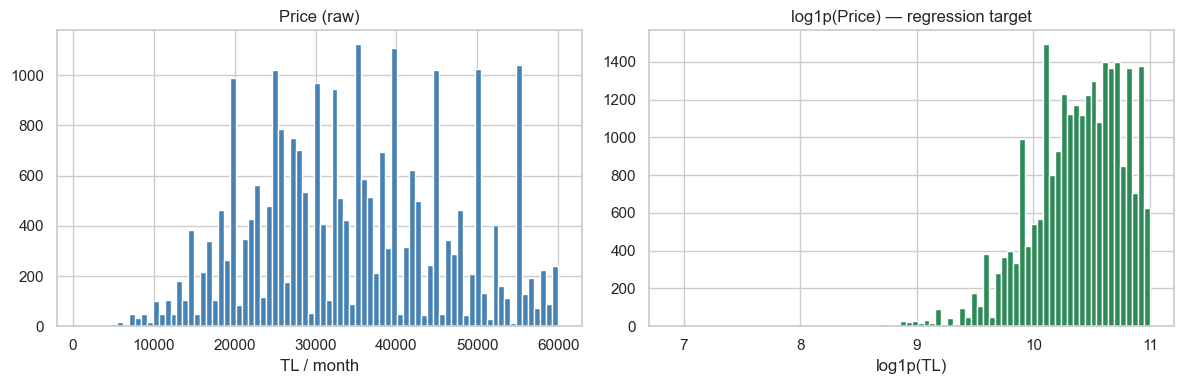

Price stats (raw):
count    25670.0
mean     34572.0
std      12103.0
min       1000.0
25%      25000.0
50%      34000.0
75%      44000.0
max      60000.0
Name: Price, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

price = df_raw['Price'].dropna()

axes[0].hist(price, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Price (raw)')
axes[0].set_xlabel('TL / month')

axes[1].hist(np.log1p(price), bins=80, color='seagreen', edgecolor='white')
axes[1].set_title('log1p(Price) — regression target')
axes[1].set_xlabel('log1p(TL)')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'eda_price_dist.png'), bbox_inches='tight')
plt.show()

print(f'Price stats (raw):\n{price.describe().round(0)}')

### NetArea distribution

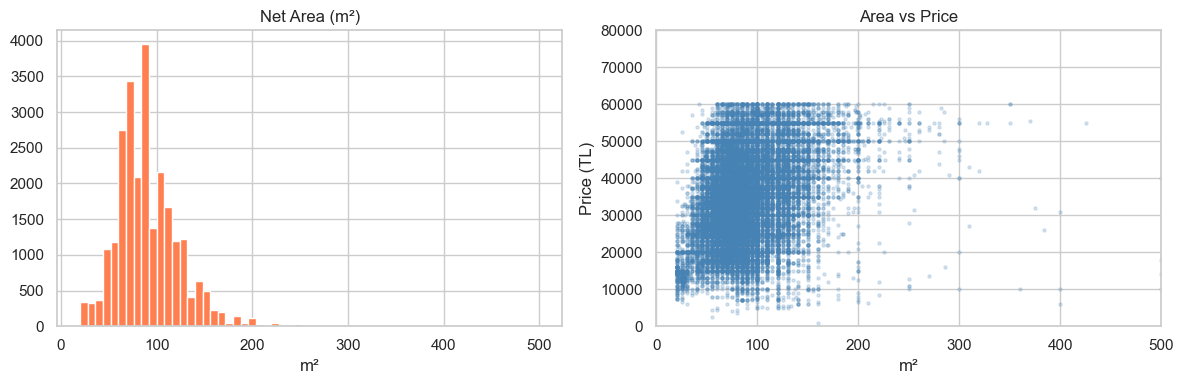

Area stats:
count    25648.0
mean        90.8
std         35.8
min         20.0
25%         70.0
50%         85.0
75%        110.0
max        880.0
Name: NetArea, dtype: float64


In [ ]:
area = df_raw['NetArea'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(area[area <= 500], bins=60, color='coral', edgecolor='white')
axes[0].set_title('Net Area (m²)')
axes[0].set_xlabel('m²')

axes[1].scatter(area, df_raw.loc[area.index, 'Price'], alpha=0.2, s=5, color='steelblue')
axes[1].set_xlim(0, 500)
axes[1].set_ylim(0, 80_000)
axes[1].set_title('Area vs Price')
axes[1].set_xlabel('m²')
axes[1].set_ylabel('Price (TL)')

plt.tight_layout()
plt.show()
print(f'Area stats:\n{area.describe().round(1)}')

### Rooms distribution

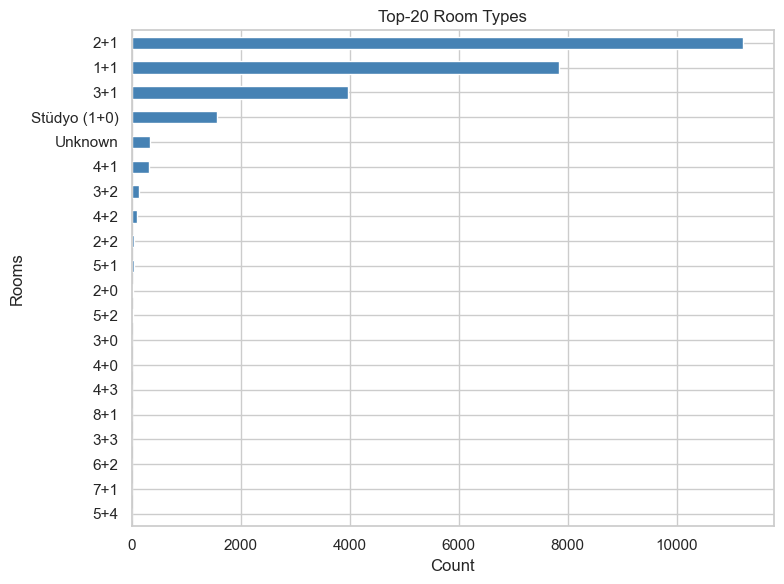

In [ ]:
rooms_counts = df_raw['Rooms'].fillna('Unknown').value_counts().head(20)
rooms_counts.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Top-20 Room Types')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### District (ilçe) distribution

Unique full District values  : 291
Unique ilçe (top-level) : 39


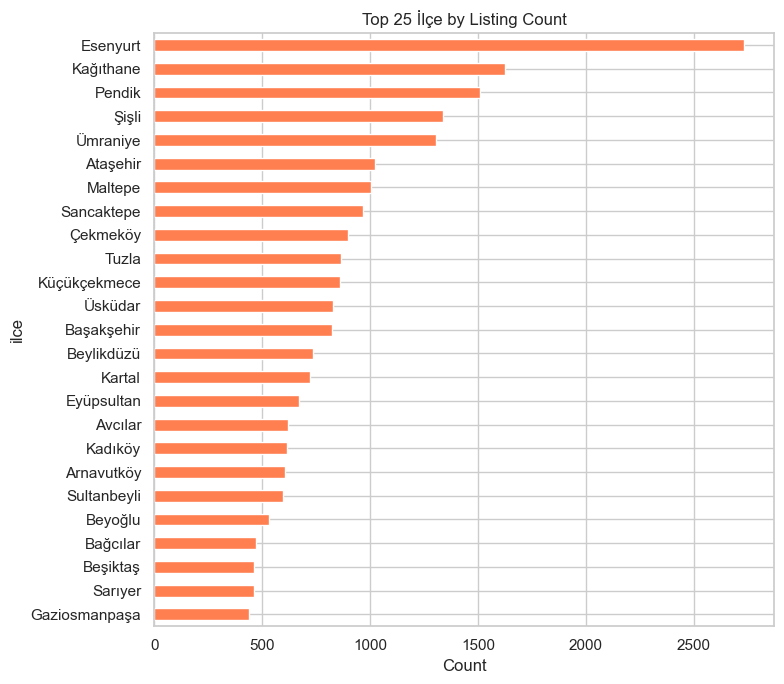

In [ ]:
# Extract ilçe (top-level district) — text before first '/'
df_raw['ilce'] = df_raw['District'].fillna('').apply(
    lambda x: x.split('/')[0].strip() if x else 'Unknown'
)

print(f'Unique full District values  : {df_raw["District"].nunique()}')
print(f'Unique ilçe (top-level) : {df_raw["ilce"].nunique()}')

top_ilce = df_raw['ilce'].value_counts().head(25)
top_ilce.plot(kind='barh', figsize=(8, 7), color='coral')
plt.title('Top 25 İlçe by Listing Count')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

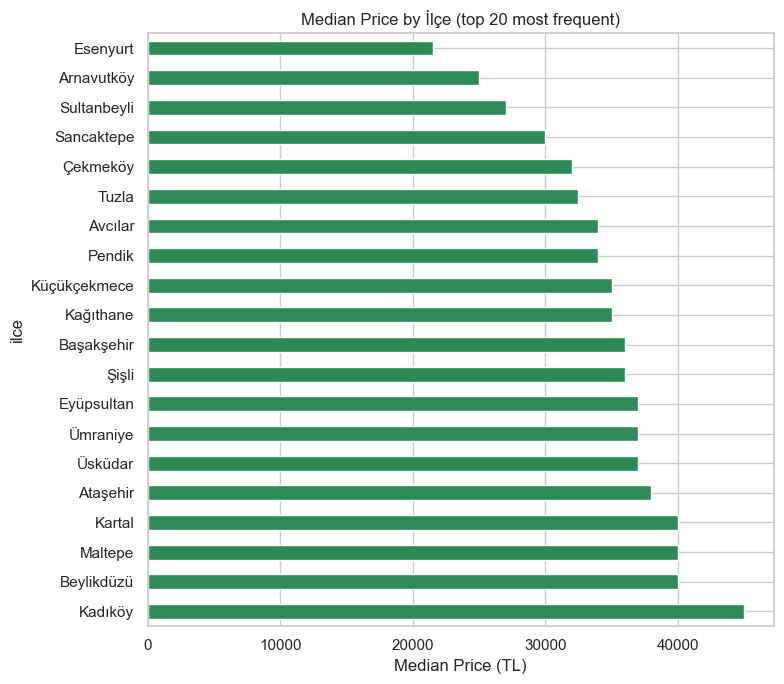

In [ ]:
# Median price per ilçe (top 20 by count)
top20_ilce = top_ilce.index[:20].tolist()
price_per_ilce = (
    df_raw[df_raw['ilce'].isin(top20_ilce)]
    .groupby('ilce')['Price']
    .median()
    .sort_values()
)
price_per_ilce.plot(kind='barh', figsize=(8, 7), color='seagreen')
plt.title('Median Price by İlçe (top 20 most frequent)')
plt.xlabel('Median Price (TL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Photo availability

Listings with valid photo on disk : 22,833 / 25,670  (88.9%)


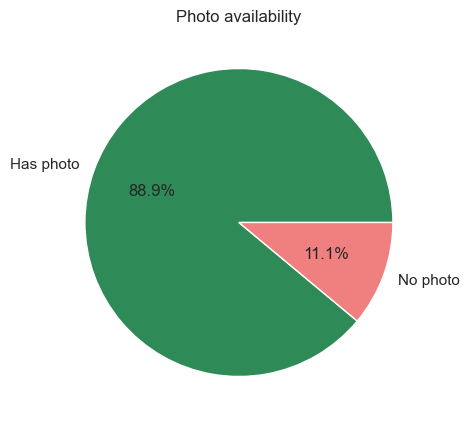

In [ ]:
def photo_exists(photo_path):
    """Check whether the photo file actually exists on disk and is > 2 KB."""
    if not isinstance(photo_path, str) or not photo_path:
        return False
    # Normalize path separators
    p = os.path.join(BASE_DIR, photo_path.replace('\\', os.sep))
    # Also try absolute path as-is
    if not os.path.exists(p):
        p = photo_path
    return os.path.exists(p) and os.path.getsize(p) > 2000

df_raw['photo_ok'] = df_raw['PhotoPath'].apply(photo_exists)

n_with_photo = df_raw['photo_ok'].sum()
print(f'Listings with valid photo on disk : {n_with_photo:,} / {len(df_raw):,}  '
      f'({n_with_photo/len(df_raw)*100:.1f}%)')

labels = ['Has photo', 'No photo']
sizes = [n_with_photo, len(df_raw) - n_with_photo]
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['seagreen', 'lightcoral'])
plt.title('Photo availability')
plt.show()

### Sample photos

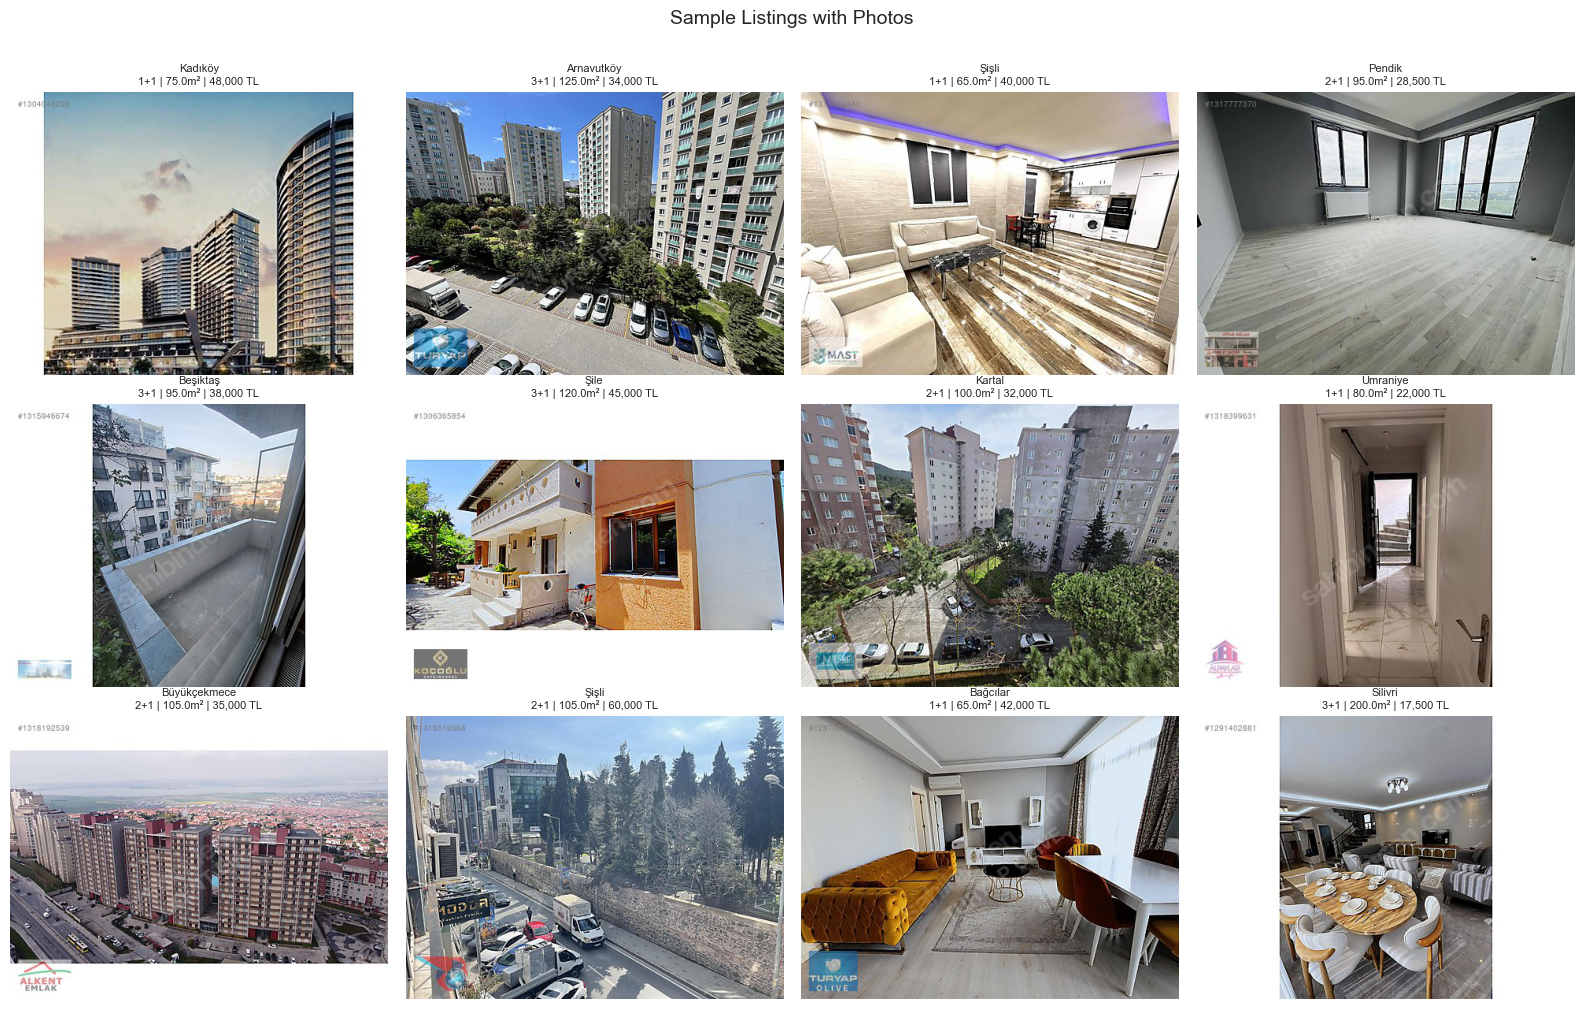

In [ ]:
sample_rows = df_raw[df_raw['photo_ok']].sample(min(12, n_with_photo), random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    p = os.path.join(BASE_DIR, row['PhotoPath'].replace('\\', os.sep))
    if not os.path.exists(p):
        p = row['PhotoPath']
    try:
        img = mpimg.imread(p)
        ax.imshow(img)
        ax.set_title(
            f"{row.get('ilce', row.get('District',''))[:15]}\n"
            f"{row.get('Rooms','')} | {row.get('NetArea','')}m² | {int(row['Price']):,} TL",
            fontsize=8
        )
    except Exception as e:
        ax.set_title(str(e), fontsize=7)
    ax.axis('off')

plt.suptitle('Sample Listings with Photos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Part B — Data Cleaning & Feature Engineering

### Keep only rows with a real photo

In [ ]:
df = df_raw[df_raw['photo_ok']].copy().reset_index(drop=True)
print(f'Working dataset: {len(df):,} rows (photo present on disk)')

Working dataset: 22,833 rows (photo present on disk)


### Price cleaning — remove outliers

In [ ]:
# Remove obviously wrong prices (< 5,000 TL — likely data errors)
before = len(df)
df = df[df['Price'] >= 5_000].copy()
print(f'Removed {before - len(df)} rows with Price < 5,000 TL')

# Remove extreme upper tail (> 200,000 TL — very rare, distort training)
before = len(df)
df = df[df['Price'] <= 200_000].copy()
print(f'Removed {before - len(df)} rows with Price > 200,000 TL')

# Log-transform target
df['log_price'] = np.log1p(df['Price'])
print(f'\nFinal: {len(df):,} rows')
print(f'log_price: min={df.log_price.min():.2f}, max={df.log_price.max():.2f}, '
      f'mean={df.log_price.mean():.2f}, std={df.log_price.std():.2f}')

Removed 8 rows with Price < 5,000 TL
Removed 0 rows with Price > 200,000 TL

Final: 22,825 rows
log_price: min=8.52, max=11.00, mean=10.38, std=0.39


### Rooms → numeric

In [ ]:
def rooms_to_numeric(val) -> float:
    """
    '2+1' → 3
    'Stüdyo (1+0)' or 'Stüdyo' → 1
    '1+0' → 1
    '5+2' → 7
    '8+' or unknown → NaN
    """
    if not isinstance(val, str):
        return np.nan
    val = val.strip()
    if 'stüdyo' in val.lower() or 'studio' in val.lower():
        # look for explicit X+Y inside parentheses, else use 1
        m = re.search(r'(\d+)\+(\d+)', val)
        return int(m.group(1)) + int(m.group(2)) if m else 1
    m = re.fullmatch(r'(\d+)\+(\d+)', val)
    if m:
        return int(m.group(1)) + int(m.group(2))
    # partial patterns like '3+' (malformed)
    m = re.match(r'(\d+)\+', val)
    if m:
        return float(m.group(1))
    return np.nan

df['rooms_num'] = df['Rooms'].apply(rooms_to_numeric)

print('rooms_num value counts:')
print(df['rooms_num'].value_counts().sort_index().to_string())
print(f'\nMissing rooms_num: {df.rooms_num.isna().sum()}')

rooms_num value counts:
rooms_num
1.0     1443
2.0     7103
3.0     9876
4.0     3553
5.0      405
6.0      118
7.0       32
8.0        4
9.0        6
10.0       2
12.0       1

Missing rooms_num: 282


In [ ]:
# Drop rows where rooms_num could not be parsed
before = len(df)
df = df[df["rooms_num"].notna()].copy()
print(f"Dropped {before - len(df)} rows with unparseable Rooms value")

# Cap at 8 — планировки >= 9 единичны и коммерческие
df["rooms_num"] = df["rooms_num"].clip(upper=8)
print(f"Remaining: {len(df):,} rows | rooms_num range: {df.rooms_num.min():.0f}-{df.rooms_num.max():.0f}")

Dropped 282 rows with unparseable Rooms value
Remaining: 22,543 rows | rooms_num range: 1-8


### NetArea — clean & scale

In [ ]:
# Fill missing NetArea with median
area_median = df["NetArea"].median()
df["NetArea"] = df["NetArea"].fillna(area_median)

# Cap at 300 m2 — квартиры > 300 м2 единичны и искажают шкалу (был max=880)
df["NetArea"] = df["NetArea"].clip(lower=15, upper=300)

print(f"NetArea: filled missing with median={area_median:.0f} m2, clipped to [15, 300]")
print(df["NetArea"].describe().round(1))

NetArea: filled missing with median=85 m2, clipped to [15, 300]
count    22543.0
mean        90.1
std         33.9
min         20.0
25%         69.0
50%         85.0
75%        109.0
max        300.0
Name: NetArea, dtype: float64


### District (ilçe) → One-Hot Encoding

In [ ]:
# Refresh ilçe column on the filtered df
df['ilce'] = df['District'].fillna('').apply(
    lambda x: x.split('/')[0].strip() if x else 'Unknown'
)
df.loc[df['ilce'] == '', 'ilce'] = 'Unknown'

# Collapse rare ilçe (< MIN_COUNT listings) into 'Other'
MIN_COUNT = 10
ilce_counts = df['ilce'].value_counts()
rare_ilce = ilce_counts[ilce_counts < MIN_COUNT].index
df.loc[df['ilce'].isin(rare_ilce), 'ilce'] = 'Other'

print(f'Unique ilçe after collapsing rare (<{MIN_COUNT}): {df.ilce.nunique()}')
print(df['ilce'].value_counts().head(20).to_string())

Unique ilçe after collapsing rare (<10): 39
ilce
Esenyurt        2398
Kağıthane       1429
Pendik          1325
Şişli           1229
Ümraniye        1093
Ataşehir         931
Maltepe          864
Sancaktepe       823
Çekmeköy         784
Tuzla            784
Küçükçekmece     746
Üsküdar          745
Başakşehir       738
Beylikdüzü       667
Kartal           606
Eyüpsultan       599
Kadıköy          550
Avcılar          545
Sultanbeyli      505
Arnavutköy       504


In [ ]:
# One-hot encode ilçe
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32)
ilce_ohe = ohe.fit_transform(df[['ilce']])
ilce_cols = [f'ilce_{c}' for c in ohe.categories_[0]]

df_ohe = pd.DataFrame(ilce_ohe, columns=ilce_cols, index=df.index)
df = pd.concat([df, df_ohe], axis=1)

print(f'Added {len(ilce_cols)} OHE columns for ilçe')

Added 39 OHE columns for ilçe


### Standard scaling of numeric features

In [ ]:
# Fit scaler ONLY on train — no data leakage
# Same split params as Part C (random_state=42, test_size=0.30)
from sklearn.model_selection import train_test_split as _tts
_idx_train, _ = _tts(df.index, test_size=0.30, random_state=42)
_train_mask = df.index.isin(_idx_train)

scaler = StandardScaler()
df.loc[_train_mask,  ["area_scaled", "rooms_scaled"]] = scaler.fit_transform(df.loc[_train_mask,  ["NetArea", "rooms_num"]])
df.loc[~_train_mask, ["area_scaled", "rooms_scaled"]] = scaler.transform(df.loc[~_train_mask, ["NetArea", "rooms_num"]])

print("Scaled features (fit on train only, no leakage):")
print(df[["area_scaled", "rooms_scaled"]].describe().round(3))

Scaled features (fit on train only, no leakage):
       area_scaled  rooms_scaled
count    22543.000     22543.000
mean        -0.011        -0.007
std          0.992         1.000
min         -2.064        -1.950
25%         -0.630        -0.856
50%         -0.162         0.239
75%          0.541         0.239
max          6.131         5.714


### Tabular feature matrix overview

In [ ]:
TAB_FEATURES = ['area_scaled', 'rooms_scaled'] + ilce_cols
print(f'Tabular features: {len(TAB_FEATURES)}')
print('  Continuous  : area_scaled, rooms_scaled')
print(f'  One-hot ilçe: {len(ilce_cols)} columns')

# Correlation with log_price
corr = df[TAB_FEATURES + ['log_price']].corr()['log_price'].drop('log_price')
top_corr = corr.abs().sort_values(ascending=False).head(10)
print('\nTop 10 features correlated with log_price:')
print(corr[top_corr.index].round(3).to_string())

Tabular features: 41
  Continuous  : area_scaled, rooms_scaled
  One-hot ilçe: 39 columns

Top 10 features correlated with log_price:
ilce_Esenyurt      -0.323
area_scaled         0.311
rooms_scaled        0.295
ilce_Arnavutköy    -0.091
ilce_Kadıköy        0.088
ilce_Kartal         0.088
ilce_Maltepe        0.085
ilce_Beşiktaş       0.072
ilce_Sultanbeyli   -0.072
ilce_Beylikdüzü     0.062


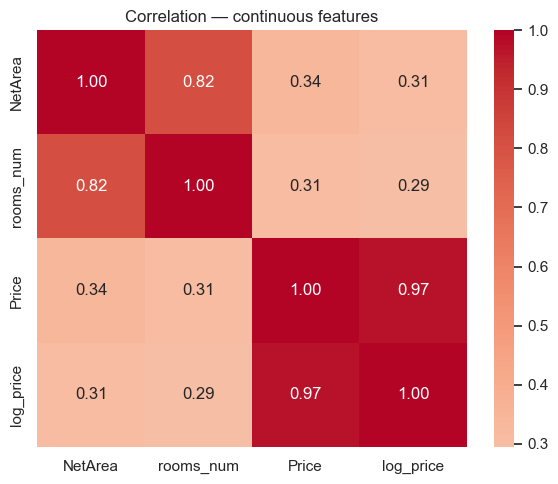

In [ ]:
# Heatmap: continuous features vs log_price
cont_cols = ['NetArea', 'rooms_num', 'Price', 'log_price']
plt.figure(figsize=(6, 5))
sns.heatmap(df[cont_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation — continuous features')
plt.tight_layout()
plt.show()

---
## Part C — Train / Val / Test Split & Save

### Normalise photo path

In [ ]:
# Store the *relative* photo path (from BASE_DIR) using forward slashes
def norm_path(p):
    if not isinstance(p, str):
        return ''
    # Convert Windows backslash to forward slash, keep relative
    return p.replace('\\', '/')

df['photo_rel'] = df['PhotoPath'].apply(norm_path)
print(df['photo_rel'].head(3).to_string())

0     Data/Istanbul/Images/928255078/photo_1.jpg
1    Data/Istanbul/Images/1236064044/photo_1.jpg
2    Data/Istanbul/Images/1318233893/photo_1.jpg


### Split  70 / 15 / 15

In [ ]:
# First split: 70% train — 30% (val + test)
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42)

# Second split: 50% of 30% → 15% val, 15% test
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42)

df_train = df_train.copy()
df_val = df_val.copy()
df_test = df_test.copy()

df_train['split'] = 'train'
df_val['split'] = 'val'
df_test['split'] = 'test'

print(f'Train: {len(df_train):>5,} ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val: {len(df_val):>5,} ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test: {len(df_test):>5,} ({len(df_test)/len(df)*100:.1f}%)')

# check: no leakage
sets = [set(df_train.ListingID), set(df_val.ListingID), set(df_test.ListingID)]
assert not sets[0] & sets[1], 'Leakage train/val!'
assert not sets[0] & sets[2], 'Leakage train/test!'
assert not sets[1] & sets[2], 'Leakage val/test!'
print('No leakage — OK')

Train: 15,780 (70.0%)
Val: 3,381 (15.0%)
Test: 3,382 (15.0%)
No leakage — OK


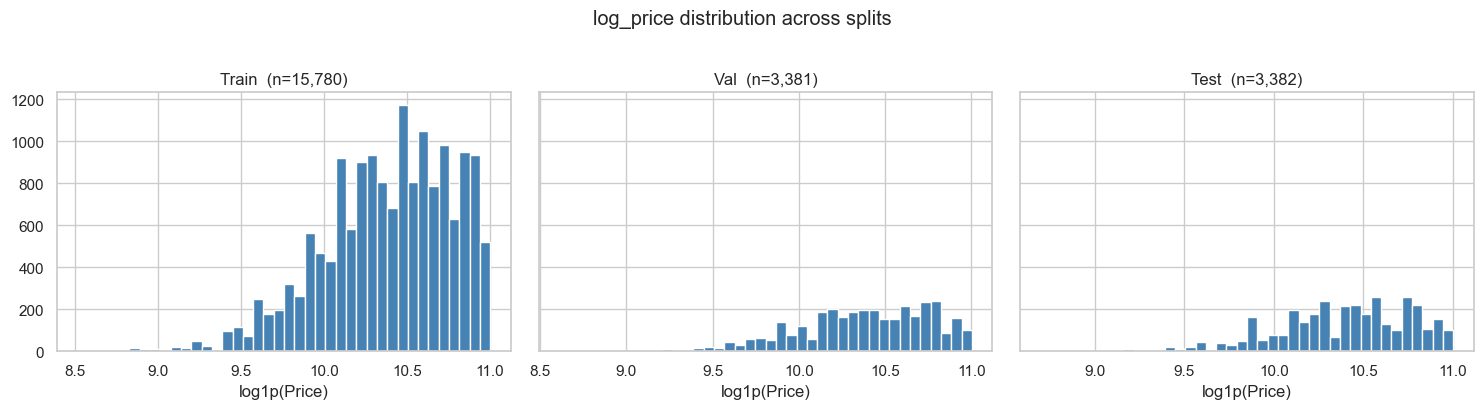

In [ ]:
# Quick price distribution check across splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, subset) in zip(axes, [('Train', df_train), ('Val', df_val), ('Test', df_test)]):
    ax.hist(subset['log_price'], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'{name}  (n={len(subset):,})')
    ax.set_xlabel('log1p(Price)')

plt.suptitle('log_price distribution across splits', y=1.02)
plt.tight_layout()
plt.show()

### Save clean dataset

In [ ]:
SAVE_COLS = (
    ['ListingID', 'split', 'photo_rel',
     'District', 'ilce', 'Rooms', 'rooms_num', 'rooms_scaled',
     'NetArea', 'area_scaled',
     'Price', 'log_price']
    + ilce_cols
)

df_clean = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_clean = df_clean[SAVE_COLS]

df_clean.to_csv(OUT_CSV, index=False, encoding='utf-8-sig')
print(f'Saved {len(df_clean):,} rows → {OUT_CSV}')
df_clean.head(3)

Saved 22,543 rows → c:\Users\sashk\OzU\DL\Data\Istanbul\data_clean.csv


,ListingID,split,photo_rel,District,ilce,Rooms,rooms_num,rooms_scaled,NetArea,area_scaled,...,ilce_Sultanbeyli,ilce_Sultangazi,ilce_Tuzla,ilce_Zeytinburnu,ilce_Çatalca,ilce_Çekmeköy,ilce_Ümraniye,ilce_Üsküdar,ilce_Şile,ilce_Şişli
0,1318389113,train,Data/Istanbul/Images/1318389113/photo_1.jpg,Çekmeköy / Taşdelen,Çekmeköy,2+1,3.0,0.239374,105.0,0.423788,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1312216685,train,Data/Istanbul/Images/1312216685/photo_1.jpg,Ataşehir / Kayışdağı,Ataşehir,1+1,2.0,-0.855500,45.0,-1.332350,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1311239583,train,Data/Istanbul/Images/1311239583/photo_1.jpg,Beylikdüzü / Gürpınar,Beylikdüzü,1+1,2.0,-0.855500,85.0,-0.161591,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Summary statistics for report

In [ ]:
print('=' * 55)
print('DATASET SUMMARY')
print('=' * 55)
print(f'Total cleaned samples    : {len(df_clean):,}')
print(f'  Train                  : {df_clean.split.eq("train").sum():,}')
print(f'  Val                    : {df_clean.split.eq("val").sum():,}')
print(f'  Test                   : {df_clean.split.eq("test").sum():,}')
print()
print(f'Tabular features         : {len(TAB_FEATURES)} (2 continuous + {len(ilce_cols)} OHE)')
print(f'Image feature (CNN embed): 224×224 RGB JPEG')
print(f'Target variable          : log1p(Price)')
print()
price_stats = df_clean['Price']
print(f'Price range              : {price_stats.min():,.0f} – {price_stats.max():,.0f} TL')
print(f'Price median             : {price_stats.median():,.0f} TL')
print(f'Price mean               : {price_stats.mean():,.0f} TL')
print()
print(f'Unique İlçe (districts)  : {df_clean.ilce.nunique()}')
print(f'Rooms range              : {df_clean.rooms_num.min():.0f} – {df_clean.rooms_num.max():.0f}')
print(f'Area range               : {df_clean.NetArea.min():.0f} – {df_clean.NetArea.max():.0f} m²')
print('=' * 55)

DATASET SUMMARY
Total cleaned samples    : 22,543
  Train                  : 15,780
  Val                    : 3,381
  Test                   : 3,382

Tabular features         : 41 (2 continuous + 39 OHE)
Image feature (CNN embed): 224×224 RGB JPEG
Target variable          : log1p(Price)

Price range              : 5,000 – 60,000 TL
Price median             : 34,000 TL
Price mean               : 34,626 TL

Unique İlçe (districts)  : 39
Rooms range              : 1 – 8
Area range               : 20 – 300 m²
